In [1]:
pip install segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 5.6 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [36]:
import os
import glob
import pandas as pd
import cv2 as cv
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torchvision.transforms import v2, InterpolationMode
from torchvision import transforms
import torchvision.transforms as transforms
from torchvision.ops import sigmoid_focal_loss
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
import segmentation_models_pytorch as smp
import torch.optim as optim
from torchvision.io import read_image, ImageReadMode
import torch.nn as nn
import random
import torch
import time
from tqdm import tqdm
from torchmetrics.classification import (BinaryPrecision,BinaryRecall,BinaryF1Score,BinaryJaccardIndex)

In [129]:
def build_segmented_dataframe(train_path, target_path):
    """
    Build a DataFrame mapping isegmented training images to their corresponding masks.
        train_path (str): str path to training images directory
        target_path (str): str path to segmentation masks directory
        
    Returns:
        pd.DataFrame: DataFrame with columns ['image_path', 'mask_path']
    """
    
    def extract_number(filename):
        match = re.search(r"\d+", filename)
        return match.group() if match else None

    # Collect available mask IDs
    target_ids = {extract_number(file)for file in os.listdir(target_path)if file.endswith(".png")}

    map_dict = {"image": [],"target":[]}

    for file in os.listdir(train_path):
        if file.endswith(".jpg"):
            img_id = extract_number(file)

            if img_id in target_ids:
                map_dict["image"].append(os.path.join(train_path, file))
                map_dict["target"].append(os.path.join(target_path, f"ISIC_{img_id}_segmentation.png"))

    df = pd.DataFrame(map_dict)

    assert not df.empty, "DataFrame is empty"    
    return df

In [123]:
def img_visualization(input_imgs_dict, title=None):
    """
    input_imgs_dict --> {"Image":img, "Mask":mask, "Target": target, "Output": output}
    All inputs are torch Tensors.
    """
    ncols = len(input_imgs_dict)
    fig, axes = plt.subplots(nrows=1, ncols=ncols, figsize=(15, 5))
    if title:
        fig.suptitle(title, fontsize=14);
        
    for i, (key, value) in enumerate(input_imgs_dict.items()):
        
        img = value.detach().cpu()
        if img.ndim == 3 and img.shape[0] == 3:
            img = img.permute(1, 2, 0) # RGB image: (3, H, W) ---> (H, W, 3)
            axes[i].imshow(img)
            
        elif img.ndim == 3 and img.shape[0] == 1:
            img = img.squeeze(0)  # (1, H, W) ---> (H, W)
            axes[i].imshow(img, cmap="gray")

        elif img.ndim == 2:
            axes[i].imshow(img, cmap="gray")
        else:
            raise ValueError(f"unsupported shape for visualization: {img.shape}")
            
        axes[i].set_title(key)
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()   


In [130]:
root_path = "/kaggle/input/isic2018-challenge-task1-data-segmentation"
train_path = root_path + "/" +"ISIC2018_Task1-2_Training_Input"
target_path = root_path + "/" +"ISIC2018_Task1_Training_GroundTruth"

df = build_segmented_dataframe(train_path, target_path)

In [138]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2594 entries, 0 to 2593
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   image   2594 non-null   object
 1   target  2594 non-null   object
dtypes: object(2)
memory usage: 40.7+ KB


In [136]:
# check mapped names
print(df.iloc[90]["image"])
print(df.iloc[90]["target"])

/kaggle/input/isic2018-challenge-task1-data-segmentation/ISIC2018_Task1-2_Training_Input/ISIC_0015958.jpg
/kaggle/input/isic2018-challenge-task1-data-segmentation/ISIC2018_Task1_Training_GroundTruth/ISIC_0015958_segmentation.png


Image shape:  torch.Size([3, 2000, 3008])
Segment shape:  torch.Size([1, 2000, 3008])


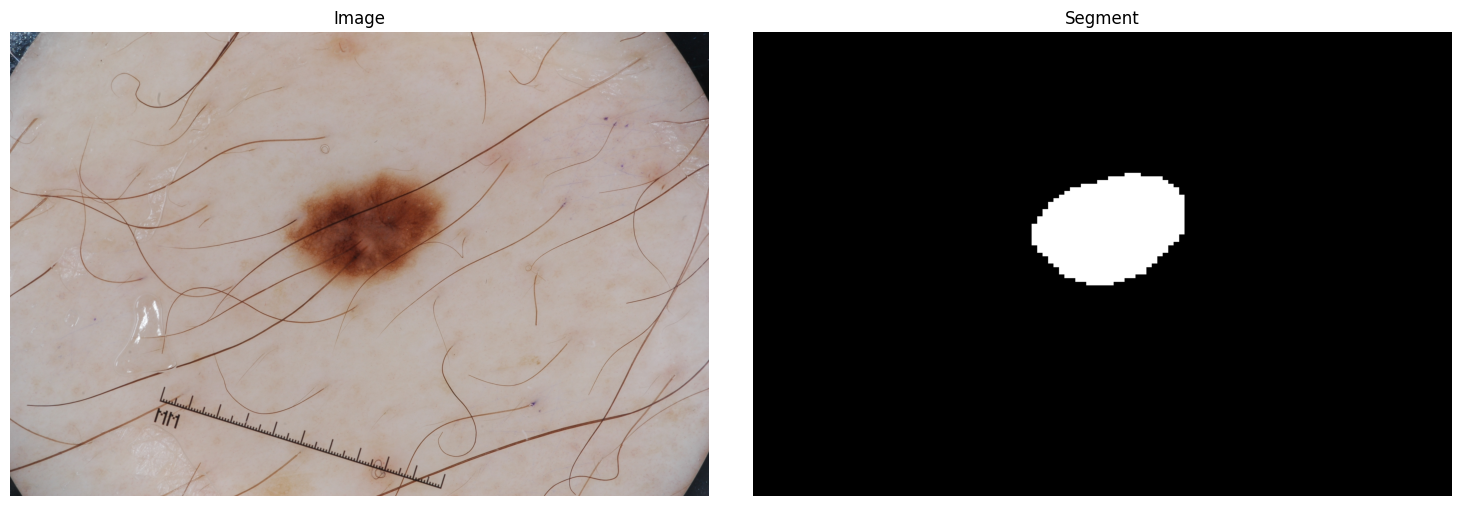

In [134]:
img = read_image(df.iloc[10]["image"])  #cv.imread(img_path)
target = read_image(df.iloc[10]["target"])  #cv.imread(target_path, cv.IMREAD_GRAYSCALE)
print("Image shape: ",img.shape)
print("Segment shape: ",target.shape)

img_visualization({"Image": img, "Segment": target})

In [ ]:
class READ_SEGMENTATION_DATA_SET(Dataset):
   def __init__(self, df, drop_pixels_percentage=None, img_size=(224, 224), augmentation_mode=False,mode="train", 
                mask_strategy='random'):
       self.df = df
       self.mask_strategy = mask_strategy
       self.drop_pixels_percentage = drop_pixels_percentage
       
       self.mode = mode
       self.augmentation_mode = augmentation_mode
    
       self.img_resize = v2.Resize(img_size, antialias=True, interpolation=InterpolationMode.BICUBIC)
       self.target_resize = v2.Resize(img_size, antialias=False, interpolation=InterpolationMode.NEAREST_EXACT) 
       
       if self.augmentation_mode:
           # Photometric augmentations (image only)
           self.img_only_aug = v2.ColorJitter(brightness=(0.7, 1.3),contrast=(0.8, 1.2))
           # Geometric augmentations (shared between image and target)
           self.img_target_aug = v2.Compose([v2.RandomHorizontalFlip(p=0.5)
                                         #,v2.RandomRotation(degrees=30,interpolation=v2.InterpolationMode.NEAREST)
                                            ])

       # Normalization uses ImageNet statistics to match the pretrained encoder
       self.img_normalization = v2.Normalize(mean=[0.485, 0.456, 0.406],std=[0.229, 0.224, 0.225])
       
   def __len__(self): 
        return len(self.df)

   def get_balanced_sampling_mask(self, target):
       """
       Drop pixels in a class-balanced manner, where a fixed percentage of the target object class and background pixels
       are randomly ignored
       Future enhancment: drop_target_percentage, drop_background_percentage
       """
       mask = torch.ones_like(target)
       # indices per class
       target_idx = torch.where(target == 1)
       background_idx = torch.where(target == 0)

       num_target_pixels = target_idx[0].shape[0]
       num_background_pixels = background_idx[0].shape[0]

       if num_target_pixels == 0 or num_background_pixels == 0:
           return mask

       # number of pixels to drop per class
       num_drop_target_pixels = int(num_target_pixels * self.drop_pixels_percentage)
       num_drop_background_pixels = int(num_background_pixels * self.drop_pixels_percentage)

       num_drop_target_pixels = max(1, num_drop_target_pixels)
       num_drop_background_pixels = max(1, num_drop_background_pixels)

       # randomly drop target pixels
       shuffled_target_idx = torch.randperm(num_target_pixels)
       target_drop_idx = shuffled_target_idx[:num_drop_target_pixels]

       mask[target_idx[0][target_drop_idx], target_idx[1][target_drop_idx]] = 0
       
       # randomly drop background pixels
       shuffled_background_idx = torch.randperm(num_background_pixels)
       background_drop_idx = shuffled_background_idx[:num_drop_background_pixels]
       
       mask[background_idx[0][background_drop_idx],background_idx[1][background_drop_idx]] = 0
       
       return mask    

    
   def get_random_sampling_mask(self, target_shape):
       """
       Create a mask by randomly sampling a percentage
       of all labeled pixels for both background and target
       (Randomly keep (1 - mask_percentage) of all pixels and ignore the rest)
       # mask values: 1 = used in loss, 0 = ignored
       """
       H, W = target_shape
       mask = torch.ones((H,W))
       num_pixels = H*W
       num_drop_pixels = int(num_pixels * self.drop_pixels_percentage)
       num_drop_pixels = max(1, num_drop_pixels)

       # randomly select pixels indices to drop
       drop_indices = torch.randperm(num_pixels)[:num_drop_pixels]

       # flatten mask and drop
       mask.view(-1)[drop_indices] = 0
       
       return mask
        
   def __getitem__(self, idx):
       """
       Returns:
       self.mode --> train, validation, test
       train -or validation- mode: image, target, mask
       evaluation mode: image, target
       test mode : image only
       """
       # ---------- Load image ----------
       img_path = self.df.iloc[idx,0]
       img = read_image(img_path, mode=ImageReadMode.RGB).float() / 255.0  # (3,H,W), RGB
       img = self.img_resize(img)

       if self.mode == "test":
           # test / inference mode
           return {"img": self.img_normalization(img)}
           
       #---------- Load target ----------
       target_path = self.df.iloc[idx,1]
       target = read_image(target_path) # (1,H,W)
       target = self.target_resize(target)
       target = target.squeeze(0)  # (H, W)
       target = (target > 0).float() # binarize (target / background), float to be compatible with the loss fun 
       if self.mode == "evaluation":
           return {"img": self.img_normalization(img), "target": target}

       # ______________ Augmentation(op) ______________  
       if self.mode == "train" and self.augmentation_mode:
           # spatial transforms must be shared, on the fly method
           img = self.img_only_aug(img)
           img, target = self.img_target_aug(img, target)
           
       if self.mask_strategy == "random":
           mask = self.get_random_mask(target.shape)
       elif self.mask_strategy == "balanced":
           mask = self.class_balanced_sampling_mask(target)    

                  
       return {"img": self.img_normalization(img), "target": target, "mask": mask}

           

print("Done")

In [ ]:
class SpatialFocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, eps=1e-8):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        #self.reduction = reduction
        self.eps = eps

    def forward(self, logits, targets, mask):
        """
        logits: the logits from the netweok for each example
        mask: same shape as target, 0 --> ignore this pixel, 1--> don't 
        targets: the tensor of the binary classification label for each pixel in the inputs (0 for the background class and 1 for the water class)
        (Note using logits for inputs instead of predictions/probabilities, because the torch function apply sigmoid)
        
        **** shapes **** 
        logits: (B, 1, H, W)
        targets: (B, C=1, H, W)
        mask:  (B, H, W)
        """

        # 1. focal loss per pixel
        focal = sigmoid_focal_loss(logits.squeeze(1),
                                   targets,
                                   alpha= self.alpha,
                                   gamma= self.gamma,
                                   reduction= "none"
                                  )

        # 2. apply mask
        focal = focal * mask.float()

        # 3. average over labeled pixels only
        return focal.sum() / (mask.sum() + self.eps)
        
    def step(self, epoch):
        # optional
        if epoch > 10:
            self.gamma = 2.0 
print("Done")

In [132]:
"""
import re

def extract_number(filename):
    match = re.search(r"\d+", filename)
    return match.group() if match else None
    
root_path = "/kaggle/input/isic2018-challenge-task1-data-segmentation"
train_path = root_path + "/" +"ISIC2018_Task1-2_Training_Input"
target_path = root_path + "/" +"ISIC2018_Task1_Training_GroundTruth"

target_ids  = {extract_number(file) for file in os.listdir(target_path) if file.endswith(".png")}

train_map = {"image": [],"target":[]}

for file in os.listdir(train_path):
    if file.endswith("jpg"):
        img_id = extract_number(file)
        if img_id in target_ids:
            train_map["image"].append(os.path.join(train_path, file))            
            train_map["target"].append(os.path.join(target_path, f"ISIC_{img_id}_segmentation.png"))

df = pd.DataFrame(data)"""

'root_path = "/kaggle/input/isic2018-challenge-task1-data-segmentation"\ntrain_path = root_path + "/" +"ISIC2018_Task1-2_Training_Input"\ntarget_path = root_path + "/" +"ISIC2018_Task1_Training_GroundTruth"\n\ntarget_ids  = {extract_number(file) for file in os.listdir(target_path) if file.endswith(".png")}\n\ntrain_map = {"image": [],"target":[]}\n\nfor file in os.listdir(train_path):\n    if file.endswith("jpg"):\n        img_id = extract_number(file)\n        if img_id in target_ids:\n            train_map["image"].append(os.path.join(train_path, file))            \n            train_map["target"].append(os.path.join(target_path, f"ISIC_{img_id}_segmentation.png"))\n\ndf = pd.DataFrame(data)'